In [1]:
data_sources = {
    "training_images": "train-images-idx3-ubyte.gz",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte.gz",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte.gz",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte.gz",  # 10,000 test labels.
}

In [2]:
import requests
import os

data_dir = "../_data"
os.makedirs(data_dir, exist_ok=True)

base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"

for fname in data_sources.values():
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print("Downloading file: " + fname)
        resp = requests.get(base_url + fname, stream=True)
        resp.raise_for_status()  # Ensure download was succesful
        with open(fpath, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=128):
                fh.write(chunk)

In [3]:
import gzip
import numpy as np

mnist_dataset = {}

# Images
for key in ("training_images", "test_images"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(
            mnist_file.read(), np.uint8, offset=16
        ).reshape(-1, 28 * 28)
# Labels
for key in ("training_labels", "test_labels"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

In [4]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

def one_hot_encoding(labels, dimension=10):
    # Define a one-hot variable for an all-zero vector
    # with 10 dimensions (number labels from 0 to 9).
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]
    # Return one-hot encoded labels.
    return one_hot_labels.astype(np.float64)

training_sample, test_sample = 1000, 1000
training_images = x_train[0:training_sample] / 255
test_images = x_test[0:test_sample] / 255

training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

In [6]:
import logging

logging.basicConfig(level=logging.INFO)

from decoupling import Algorithm
from decoupling.utils import collect_information_from_inputs

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [7]:
import jax, jax.numpy as jnp

key = jax.random.key(0)
rank = 64

training_images = jnp.asarray(training_images)
training_labels = jnp.asarray(training_labels)

In [8]:
import equinox as eqx
import optax

key, model_key = jax.random.split(key)

model = eqx.nn.MLP(
    in_size=28 * 28,
    out_size=10,
    width_size=128,
    depth=2,
    activation=jax.nn.relu,
    key=model_key,
)

def loss_fn(model, x, y):
    logits = jax.vmap(model)(x)
    return optax.softmax_cross_entropy(logits, y).mean()

@eqx.filter_jit
def make_step(model, opt_state, x, y):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

optim = optax.adam(1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

In [9]:
num_steps = 500
batch_size = 128

def get_batch_indices(k, n=training_sample, b=batch_size):
    return jax.random.choice(k, n, (b,), replace=False)

for step, seed in enumerate(jax.random.split(key, num_steps)):
    batch_idx = get_batch_indices(seed)
    x, y = training_images[batch_idx], training_labels[batch_idx]
    model, opt_state, loss = make_step(model, opt_state, x, y)
    if (step+1) % 50 == 0:
        print(f'step {step+1:4d}  loss {loss:.4f}')

step   50  loss 0.3738
step  100  loss 0.2095
step  150  loss 0.0744
step  200  loss 0.0563
step  250  loss 0.0188
step  300  loss 0.0143
step  350  loss 0.0093
step  400  loss 0.0075
step  450  loss 0.0055
step  500  loss 0.0030


In [10]:
test_images_j = jnp.asarray(test_images)
test_labels_j = jnp.asarray(test_labels)

def accuracy(model, x, y):
    preds = jnp.argmax(jax.vmap(model)(x), axis=-1)
    targets = jnp.argmax(y, axis=-1)
    return jnp.mean(preds == targets)

print('test accuracy:', accuracy(model, test_images_j, test_labels_j))

test accuracy: 0.85800004


In [11]:
X, Y, J = collect_information_from_inputs(model, training_images)
X.shape, Y.shape, J.shape

((1000, 784), (1000, 10), (10, 784, 1000))

In [12]:
decoupling = Algorithm(32, key, splines_dof=20).run(X, Y, J)

[Seed 1/1]: 100%|███████████████████████████████| 20/20 [00:37<00:00,  1.85s/it, error=0.1637, best=0.1637 (19), rcond=4.3e-08]


In [13]:
accuracy(decoupling, test_images_j, test_labels_j)

Array(0.85, dtype=float32)

In [14]:
accuracy(model, test_images_j, test_labels_j)

Array(0.85800004, dtype=float32)

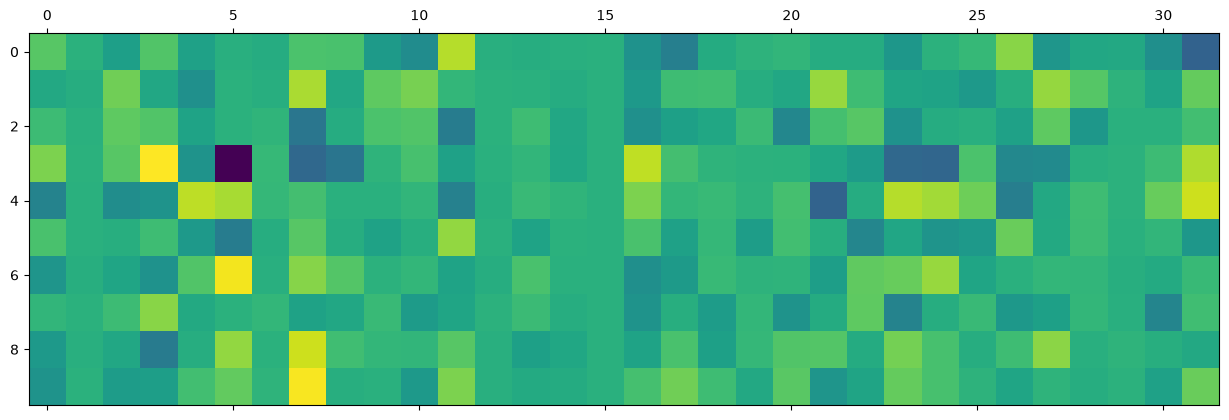

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.matshow(decoupling.W)

In [17]:
from typing import Callable
import jax.tree_util as jtu

class Linear(eqx.Module):
    weight: jax.Array

    def __init__(self, weight):
        self.weight = weight

    def __call__(self, x):
        return self.weight @ x

class NN(eqx.Module):
    fc1: Linear
    fc2: Linear
    activations: Callable

    def __init__(self, decoupling):
        self.fc1 = Linear(decoupling.V.T)   # (rank, in_size)  = (32, 784)
        self.fc2 = Linear(decoupling.W)     # (out_size, rank) = (10, 32)
        self.activations = decoupling.internals

    def __call__(self, x):
        a = self.fc1(x)
        b = self.activations(a)
        c = self.fc2(b)
        return c

def to_nn(decoupling):
    nn = NN(decoupling)
    filter_spec = jtu.tree_map(lambda _: True, nn)
    filter_spec = eqx.tree_at(
        lambda m: m.activations,
        filter_spec,
        replace_fn=lambda _: False,   # keep the splines fixed, only fine-tune V/W
    )
    return nn, filter_spec

In [18]:
nn, filter_spec = to_nn(decoupling)
print(nn)

optim = optax.adam(1e-3)
diff_model, static_model = eqx.partition(nn, filter_spec)
opt_state = optim.init(diff_model)

def loss_fn(diff_model, static_model, x, y):
    model = eqx.combine(diff_model, static_model)
    logits = jax.vmap(model)(x)
    return optax.softmax_cross_entropy(logits, y).mean()

@eqx.filter_jit
def make_step(model, filter_spec, opt_state, x, y):
    diff_model, static_model = eqx.partition(model, filter_spec)
    loss, grads = eqx.filter_value_and_grad(loss_fn)(diff_model, static_model, x, y)
    updates, opt_state = optim.update(grads, opt_state, diff_model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

NN(
  fc1=Linear(weight=f32[32,784]),
  fc2=Linear(weight=f32[10,32]),
  activations=<bound method Decoupling.internals of <decoupling.result.result.Decoupling object at 0x7f4ad8133380>>
)


In [19]:
num_steps = 5000

for step, seed in enumerate(jax.random.split(key, num_steps)):
    batch_idx = get_batch_indices(seed)
    x, y = training_images[batch_idx], training_labels[batch_idx]
    nn, opt_state, loss = make_step(nn, filter_spec, opt_state, x, y)
    if (step + 1) % 50 == 0:
        print(f'step {step+1:4d}  loss {loss:.10f}')

step   50  loss 0.0064973747
step  100  loss 0.0021406210
step  150  loss 0.0008115598
step  200  loss 0.0009042803
step  250  loss 0.0006087116
step  300  loss 0.0005184767
step  350  loss 0.0004165731
step  400  loss 0.0003821008
step  450  loss 0.0002968223
step  500  loss 0.0001781547
step  550  loss 0.0001632339
step  600  loss 0.0001618984
step  650  loss 0.0001320543
step  700  loss 0.0001202820
step  750  loss 0.0000887775
step  800  loss 0.0001319890
step  850  loss 0.0000719230
step  900  loss 0.0000686141
step  950  loss 0.0000647992
step 1000  loss 0.0000587342
step 1050  loss 0.0000505686
step 1100  loss 0.0000417714
step 1150  loss 0.0000695900
step 1200  loss 0.0000340961
step 1250  loss 0.0000491325
step 1300  loss 0.0000370178
step 1350  loss 0.0000377433
step 1400  loss 0.0000266201
step 1450  loss 0.0000277021
step 1500  loss 0.0000380525
step 1550  loss 0.0000261397
step 1600  loss 0.0000278181
step 1650  loss 0.0000220878
step 1700  loss 0.0000245247
step 1750  los

In [20]:
print('MLP accuracy:            ', accuracy(model, test_images_j, test_labels_j))
print('decoupled (CPD) accuracy:', accuracy(decoupling, test_images_j, test_labels_j))
print('fine-tuned accuracy:     ', accuracy(nn, test_images_j, test_labels_j))

MLP accuracy:             0.85800004
decoupled (CPD) accuracy: 0.85
fine-tuned accuracy:      0.85300004


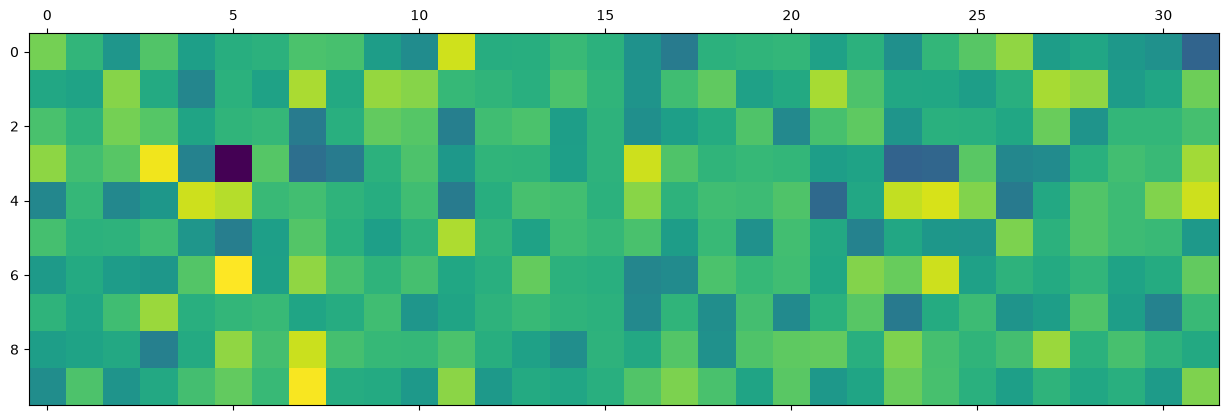

In [22]:
plt.matshow(nn.fc2.weight)